## Adding MMP to PyHDD

In [1]:
import numpy as np
import control as ct
import control.matlab as ctm
import plant
import utils
import matplotlib.pyplot as plt
from function_simulation import Function_simulation, Function_simulation_clean
from scipy import signal
from mfmdob_functions import signal_recovery_iir, wave_generator


     ______          _     _  _____    _____   
    (_____ \        | |   | |(____ \  (____ \  
     _____) ) _   _ | |__ | | _   \ \  _   \ \ 
    |  ____/ | | | ||  __)| || |   | || |   | |
    | |      | |_| || |   | || |__/ / | |__/ / 
    |_|       \__  ||_|   |_||_____/  |_____/  
              (____/                            
    
(v0.1.0)


C:\ProgramData\anaconda3\Lib\site-packages\scipy\signal\_filter_design.py:1746: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  warnings.warn("Badly conditioned filter coefficients (numerator): the "


In [3]:
# runs case 2, room temperature with nominal model
sim_result = Function_simulation(
    plant.Sys_Pc_vcm_c2,
    plant.Sys_Pc_pzt_c2,
    utils.get_Sys_Cd_vcm(),
    utils.get_Sys_Fm_vcm(),
    utils.get_Sys_Cd_pzt(),
    utils.get_Sys_Fm_pzt(),
    plant.Ts,
    plant.Mr_f,
    2
)

In [5]:
############################## parameter cell ##############################
Ts = plant.Ts
F_plant = 1/Ts
Mr_f = plant.Mr_f # upsampling by 2
Mr_P = 20
Ts_fast = Ts / Mr_f 
F_fast = 1/Ts_fast
step = int(Mr_P / Mr_f)   # 20/2 = 10, factor for down-sampling from simulation time to fast-sampling time

# MMP settings
L_mmp = 6
a_g = 0.94
F_RECOVER = np.array([4220, 4380, 5072, 5850, 6660, 7670, 9200])
F_DIST_ALL = np.array([
    2200, 2937, 3300, 3545, 3980,
    4220, 4380, 5072, 5370, 5850,
    6660, 7670, 9200,
])

# DOB / filtering settings
SUBTRACT_DF_IN_DOB = False  # False => dhat = dp + P_vcm*df; True => dhat ~= dp
HP_ORDER = 4
HP_CUTOFF_HZ = 1000

# Plotting / metrics settings
T_PLOT_START = 0.01
T_PLOT_END = None  # None uses end of signal
T_RMS_START = 0.10
T_FFT_START = 0.01
FFT_XLIM_FULL = (1000, F_fast / 2)
FFT_XLIM_DIST = (2000, 10000)

# Output settings
SAVE_FIGURES = True
FIG_DIR = "plot_result"

print(f"Plant sampling frequency = {F_plant/1000:.1f} kHz")
print(f"Fast/MR-F sampling frequency = {F_fast/1000:.1f} kHz")
print(f"Sparse MMP sampling frequency = {F_fast/L_mmp/1000:.1f} kHz")
print(f"Simulation-to-fast downsample step = {step}")

Plant sampling frequency = 50.4 kHz
Fast/MR-F sampling frequency = 100.8 kHz
Sparse MMP sampling frequency = 16.8 kHz
Simulation-to-fast downsample step = 10


Relative RMS Error with HP = 11.987%
Fit = 88.013%


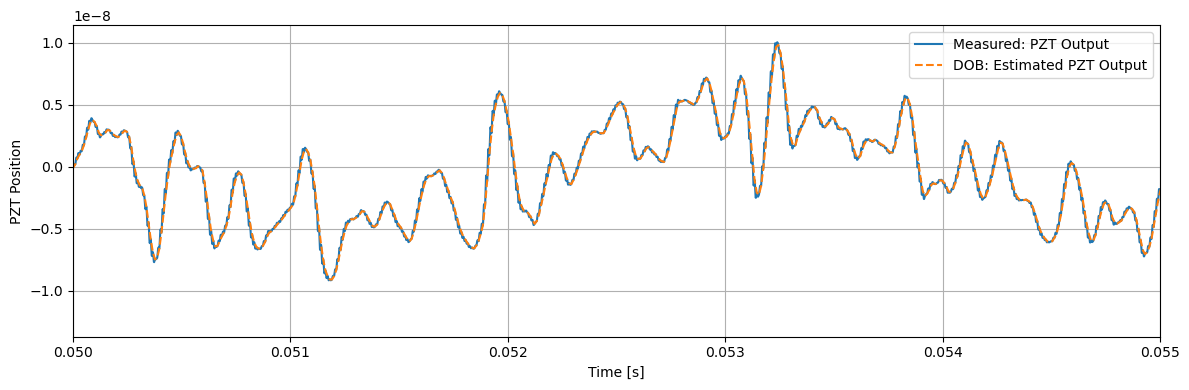

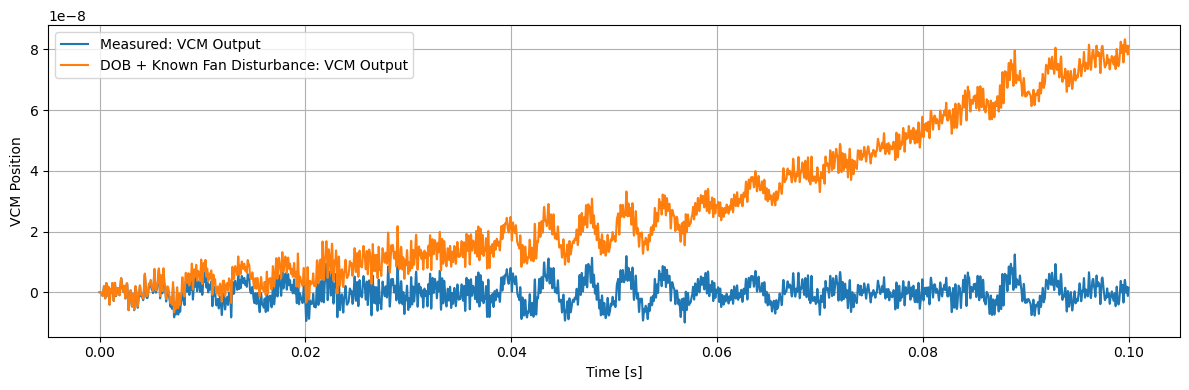

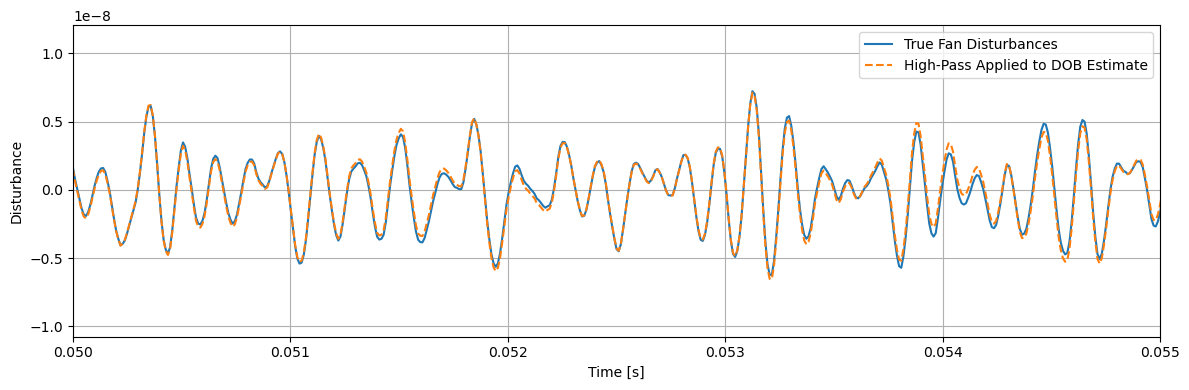

In [11]:
############################## running simulation for DOB output ##############################

##### Acquiring system models and discretization ######
# models of filter and plant for PZT and VCM from simulation (this is the exact model)
Sys_Fm_pzt = utils.get_Sys_Fm_pzt()
Sys_Fm_vcm = utils.get_Sys_Fm_vcm()
Sys_Pc_pzt = plant.Sys_Pc_pzt_c2
Sys_Pc_vcm = plant.Sys_Pc_vcm_c2
# discretization of plant at fast rate
Sys_Ppzt_d = ctm.c2d(ctm.ss(Sys_Pc_pzt), Ts_fast)
Sys_Pvcm_d = ctm.c2d(ctm.ss(Sys_Pc_vcm), Ts_fast)

###### data output ######
# get simulation output for plants
t = sim_result['time'] # runs at 1000.8 kHz, simulation time
yc_vcm_all = np.asarray(sim_result['yc_vcm']).squeeze()
yc_pzt_all = np.asarray(sim_result['yc_pzt']).squeeze()
yc_pzt_fast = yc_pzt_all[::step] # downsampling from simulation output which is 10x faster than fast sampling time
yc_vcm_fast = yc_vcm_all[::step]
yc = np.asarray(sim_result['yc']).squeeze()[::step] # output at the fast sampling time
d_p = np.asarray(sim_result['dp']).squeeze()[::step] # getting true output

##### DOB design #####
# DOB design: controller output -> multirate filter -> PZT or VCM plant
Sys_pzt_dob = Sys_Ppzt_d * Sys_Fm_pzt # PZT
Sys_vcm_dob = Sys_Pvcm_d * Sys_Fm_vcm # VCM

##### simulating output of DOB on PZT or VCM ######
# PZT
u_all = np.asarray(sim_result['ud_pzt']).squeeze()
t_all = np.asarray(sim_result['time']).squeeze()
u_fast = u_all[::step] # downsample input and output
t_fast = t_all[::step]
t_fast = np.arange(len(u_fast)) * Ts_fast
yhat_pzt, t_dob, _ = ctm.lsim(Sys_pzt_dob, U=u_fast, T=t_fast) # lsim for pzt output
# VCM, actual output y_vcm = F_vcm * P_vcm * ud_vcm + P_vcm * d_f
u_all = np.asarray(sim_result['ud_vcm']).squeeze()
df_all = np.asarray(sim_result['df']).squeeze() # disturbance from RRO and other disturbances at VCM
u_fast = u_all[::step] # down sampling
df_fast = df_all[::step]
yhat_vcm, t_lsim, _ = ctm.lsim(Sys_vcm_dob, U=u_fast,T=t_fast) # lsim for \hat{P}_{cv} = F_vcm * P_vcm
y_df, t_dob, _ = ctm.lsim(Sys_Pvcm_d, U=df_fast, T=t_fast) # lsim for P_{cv}, using fan disturbance (unknown in real cases)
y_vcm_combined = yhat_vcm + y_df # combine DOB with disturbance input from VCM
# this is the fast sampling disturbance observer of the estimated fan disturbance, \hat{d}_p \approx d_p, but contains drift
dhat_p = yc - yhat_pzt.squeeze() - yhat_vcm.squeeze()
fs_fast = 1 / Ts_fast

##### Applying high-pass filter #####
# fix drift issues
# use of filtfilt() results in much better filter because of forward and backward filter applied, removes phase error, but is only done offline
# lfilter() can be used online
"""
# High-pass difference filter: y[n] = x[n] - x[n-1]
b_hp = np.array([1, -1])
a_hp = np.array([1])

# Elliptic high-pass
b, a = signal.ellip(4, 0.5, 40, fc, btype='highpass', fs=fs_fast)
dhat_p_hp = signal.lfilter(b, a, dhat_p) 

# Chebyshev high-pass
b, a = signal.cheby1(4, 0.5, fc, btype='highpass', fs=fs_fast)
dhat_p_hp = signal.lfilter(b, a, dhat_p)

# Butterworth high-pass FIR
b_hp, a_hp = signal.butter(N=4, Wn=fc, btype='highpass', fs=fs_fast)
dhat_p_hp = signal.lfilter(b_hp, a_hp, dhat_p)

# Butterworth high-pass IIR
sos = signal.butter(N=4, Wn=fc, btype='highpass', fs=fs_fast, output='sos')
dhat_p_hp = signal.sosfilt(sos, dhat_p)


"""
# Butterworth high-pass IIR
fc = 800     # Hz
b_hp, a_hp = signal.butter(N=4, Wn=fc, btype='highpass', fs=fs_fast)
dhat_p_hp = signal.filtfilt(b_hp, a_hp, dhat_p)
# calculating errors
rms_err_hp = np.sqrt(np.mean((d_p - dhat_p_hp)**2))
rms_true = np.sqrt(np.mean(d_p**2))
rel_err_hp = rms_err_hp / rms_true
fit = 100 * (1 - rel_err_hp)
print(f"Relative RMS Error with HP = {100*rel_err_hp:.3f}%")
print(f"Fit = {fit:.3f}%")


##### Plotting #####
# t_plot = 0.05
#t_end = t_plot + t[-1]*0.05
# idx = (t_fast >= t_plot) & (t_fast <= t_end)
t_plot_start = 0.05
t_plot_end = t_plot_start + t[-1]*0.05
plot_range = [t_plot_start, t_plot_end]
# PZT output plot
plt.figure(figsize=(12,4))
plt.plot(t, sim_result['yc_pzt'], label='Measured: PZT Output')
plt.plot(t_dob, yhat_pzt, '--', label='DOB: Estimated PZT Output')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('PZT Position')
plt.xlim(plot_range)
plt.tight_layout()
plt.show()
# VCM output plot
plt.figure(figsize=(12,4))
plt.plot(t, sim_result['yc_vcm'], label='Measured: VCM Output')
plt.plot(t_dob, y_vcm_combined, label='DOB + Known Fan Disturbance: VCM Output')
#plt.plot(t_fast, y_df, label='Output: Pcv*d_f') # y_df and y_hat_vcm have "drift"
#plt.plot(t_lsim, y_hat_vcm, '--', label='DOB: Estimate of VCM Output')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('VCM Position')
# plt.xlim(plot_range)
plt.tight_layout()
plt.show()
# plot of actual vs estimated fan disturbance
plt.figure(figsize=(12,4))
plt.plot(t_fast, d_p, label='True Fan Disturbances')
# plt.plot(t_fast, dhat_p, ':', label='DOB Estimate')
plt.plot(t_fast, dhat_p_hp, '--', label='High-Pass Applied to DOB Estimate')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Disturbance')
plt.xlim(plot_range)
plt.tight_layout()
plt.show()

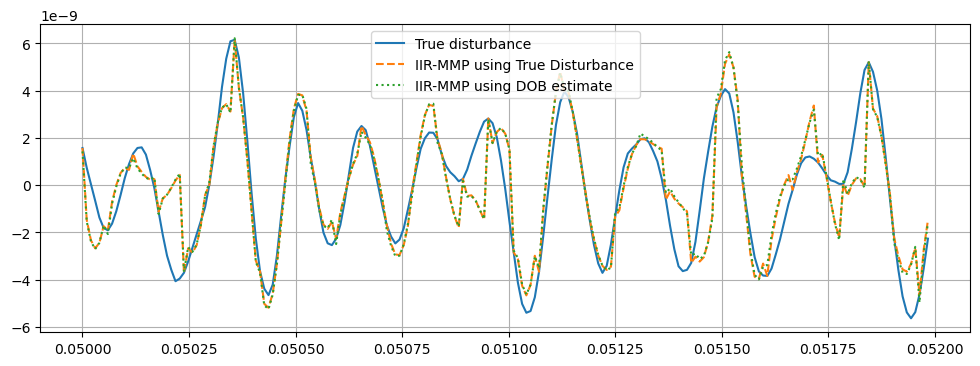

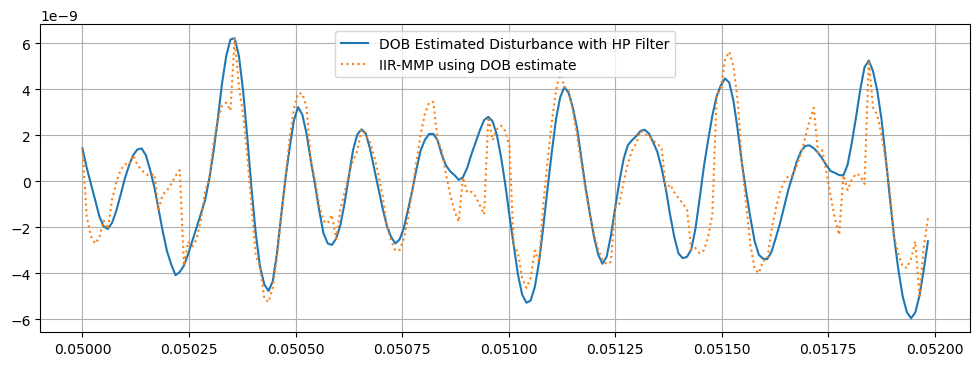

In [25]:
############################## running MMP on the DOB outputs ##############################
# Downsample by L = 6 -> 100.8 -> 16.8 kHz
a_g = 0.94 # override global settings

##### IIR-MMP reconstruction ######
# make outputs sparse by a factor of L = 6
dhat_p_slow = dhat_p_hp[::L_mmp] # DOB with highpass
dp_slow = d_p[::L_mmp] # actual fan disturbance sampling at 16.8 Hz
# Disturbance frequencies: 2200, 2937, 3300, 3545, 3980, 4220, 4380, 5072, 5370, 5850, 6660, 7670, 9200
#f_hz = np.array([5072, 5370, 5850, 7670, 9200])
f_hz = np.array([4220, 4380, 5072, 5850, 6660, 7670, 9200]) # this is the maximum before instability
# disturbance estimate using slow estimated DOB signal
dhat_mmp = signal_recovery_iir(input_signal=dhat_p_slow, f_hz=f_hz, t_fs=Ts_fast, a_g=a_g, L=L_mmp)
# disturbance estimate using slow estimated true disturbance
dp_mmp = signal_recovery_iir(input_signal=dp_slow, f_hz=f_hz, t_fs=Ts_fast, a_g=a_g, L=L_mmp)
# match dimensions of the signal recovery
N = min(len(dhat_mmp), len(dp_mmp), len(d_p), len(dhat_p_hp)) # size of simulation
d_p = d_p[:N]
dhat_p_hp = dhat_p_hp[:N]
dp_mmp = dp_mmp[:N]
dhat_mmp = dhat_mmp[:N]
t_sim = np.arange(N) * Ts_fast

##### plotting #####
t_start = 0.05
t_end = t_start + Ts_fast*200
idx = (t_sim >= t_start) & (t_sim <= t_end)

# signal plots
plt.figure(figsize=(12,4))
plt.plot(t_sim[idx], d_p[idx], label='True disturbance')
plt.plot(t_sim[idx], dp_mmp[idx], '--', label='IIR-MMP using True Disturbance')
plt.plot(t_sim[idx], dhat_mmp[idx], ':', label='IIR-MMP using DOB estimate')
plt.grid(True)
plt.legend()
plt.savefig('plot_result/mmp_output_ss.pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t_sim[idx], dhat_p_hp[idx], label='DOB Estimated Disturbance with HP Filter')
plt.plot(t_sim[idx], dhat_mmp[idx], ':', label='IIR-MMP using DOB estimate')
plt.grid(True)
plt.legend()
plt.show()

RMS Error = 1.545022e-09
Relative RMS Error = 56.887%
Relative RMS Error for DOB = 57.228%
Fit = 42.772%


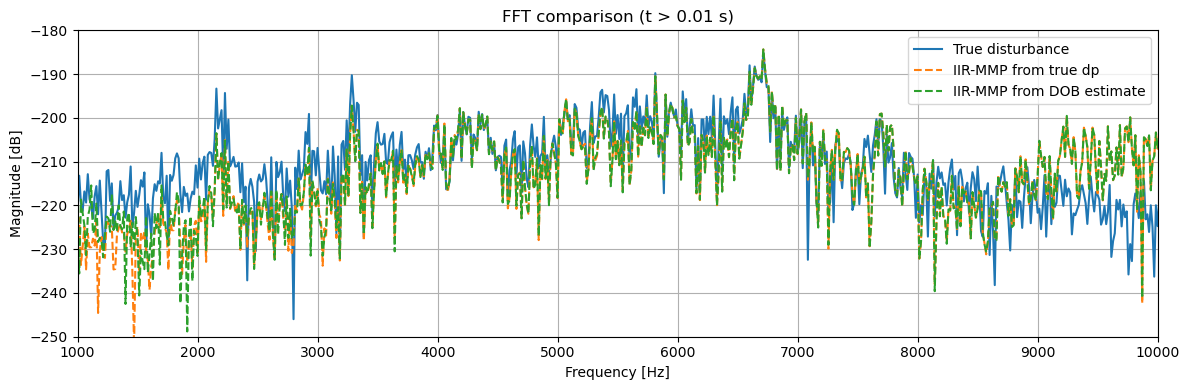

In [31]:
# steady values
t_steady_start = 0.03
idx0 = np.searchsorted(t_sim, t_steady_start)
d_p_ss = d_p[idx0:] # true disturbance at steady state
dhat_p_ss = dhat_p_hp[idx0:]
dp_mmp_ss = dp_mmp[idx0:] # reconstructed signal at steady state using true disturbance
dhat_mmp_ss = dhat_mmp[idx0:] # reconstructed signal at steady state using estimated
# error
rms_err = np.sqrt(np.mean((d_p_ss - dp_mmp_ss)**2)) # error using true disturbance for MMP
rms_err_hat = np.sqrt(np.mean((d_p_ss - dhat_mmp_ss)**2)) # error using DOB estimated disturbance for MMP
rms_true = np.sqrt(np.mean(d_p_ss**2)) # RMS of true disturbance
rel_err = rms_err / rms_true # relative error using MMP with true disturbance
rel_err_hat = rms_err_hat / rms_true # relative error using MMP with estimated DOB
fit = 100 * (1 - rel_err_hat) # fit using estimated DOB
print(f"RMS Error = {rms_err:.6e}")
print(f"Relative RMS Error = {100*rel_err:.3f}%")
print(f"Relative RMS Error for DOB = {100*rel_err_hat:.3f}%")
print(f"Fit = {fit:.3f}%")

###### spectral analysis ######
# Remove DC
d_p_ss = d_p_ss - np.mean(d_p_ss)
dp_mmp_ss = dp_mmp_ss - np.mean(dp_mmp_ss)
dhat_mmp_ss = dhat_mmp_ss - np.mean(dhat_mmp_ss)
# FFT frequency range
N_fft = min(len(d_p_ss), len(dp_mmp_ss), len(dhat_mmp_ss))
freq = np.fft.rfftfreq(N_fft, d=Ts_fast)
Dp = np.fft.rfft(d_p_ss)
Dmmp_dp = np.fft.rfft(dp_mmp_ss)
Dmmp_dhat = np.fft.rfft(dhat_mmp_ss)
mag_dp_db = 20*np.log10(np.abs(Dp)/N_fft + 1e-30)
mag_mmp_dp_db = 20*np.log10(np.abs(Dmmp_dp)/N_fft + 1e-30)
mag_mmp_dhat_db = 20*np.log10(np.abs(Dmmp_dhat)/N_fft + 1e-30)

# FFT plots
plt.figure(figsize=(12,4))
plt.plot(freq, mag_dp_db, label='True disturbance')
plt.plot(freq, mag_mmp_dp_db, '--', label='IIR-MMP from true dp')
plt.plot(freq, mag_mmp_dhat_db, '--', label='IIR-MMP from DOB estimate')
plt.grid(True)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('FFT comparison (t > 0.01 s)')
plt.xlim([1000, 10000])  # adjust as desired
plt.ylim([-250, -180])
plt.tight_layout()
plt.savefig('plot_result/fft_comparison_full_range.pdf', bbox_inches='tight')
plt.show()

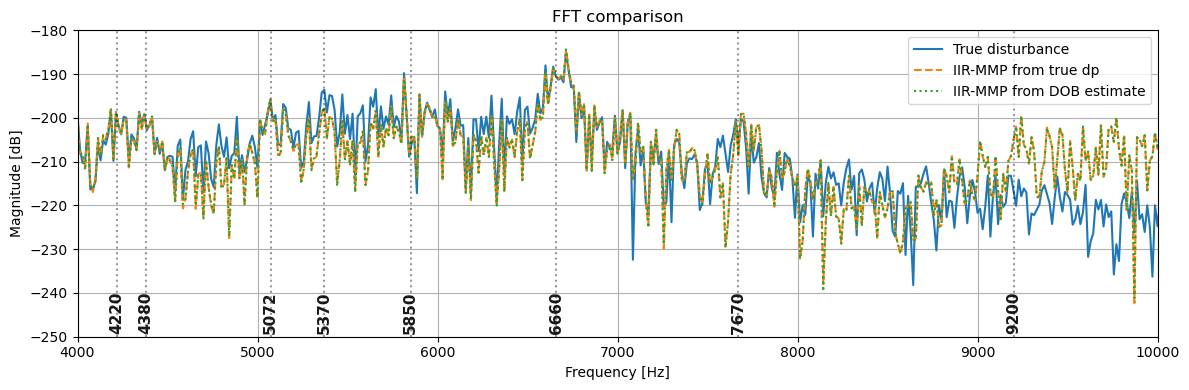

In [35]:
##### plotting upclose #####
f_dist = [4220, 4380, 5072, 5370, 5850,6660, 7670, 9200]

plt.figure(figsize=(12,4))
plt.plot(freq, mag_dp_db, label='True disturbance')
plt.plot(freq, mag_mmp_dp_db, '--', label='IIR-MMP from true dp')
plt.plot(freq, mag_mmp_dhat_db, ':', label='IIR-MMP from DOB estimate')

ax = plt.gca()
for f in f_dist:
    ax.axvline(
        x=f,
        color='k',
        linestyle=':',
        alpha=0.4
    )

    ax.text(
        f,
        0.01,                    # 1% above bottom
        f'{f}',
        rotation=90,
        fontsize=11,             # larger text
        fontweight='bold',       # darker/bolder
        color='k',
        alpha=0.9,
        transform=ax.get_xaxis_transform(),
        ha='center',             # centered on frequency
        va='bottom'
    )

plt.grid(True)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('FFT comparison')
plt.xlim([4000, 10000])
plt.ylim([-250, -180])

plt.tight_layout()
plt.savefig('plot_result/fft_comparison.pdf', bbox_inches='tight')

plt.savefig(
    'fft_comparison.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()



In [ ]:
# Q filter bode plot MMP to show the notches
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from mfmdob_functions import mmp_coeff

Ts_fast = plant.Ts / plant.Mr_f
fs_fast = 1 / Ts_fast

L = 6
a_g = 0.99
Ts_slow = L * Ts_fast
fs_slow = 1 / Ts_slow
f_nyq = fs_slow / 2

f_hz = np.array([5072, 5850, 7670, 9200])

w_kiir, Bpara = mmp_coeff(f_hz=f_hz, t_fs=Ts_fast, a_g=a_g, L=L)

f_plot = np.linspace(1, 10000, 5000)
omega = 2 * np.pi * f_plot * Ts_slow

plt.figure(figsize=(12,5))

for k in range(w_kiir.shape[1]):
    b = w_kiir[:, k]
    a = Bpara

    _, H = signal.freqz(b, a, worN=omega)

    mag_db = 20*np.log10(np.abs(H))

    plt.plot(f_plot, mag_db, label=f'$W_{k+1}(z)$')

for fd in f_hz:
    plt.axvline(fd, color='k', linestyle=':', alpha=0.35)
    plt.text(fd, 0.02, f'{fd}', rotation=90,
             transform=plt.gca().get_xaxis_transform(),
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

plt.axvline(f_nyq, color='r', linestyle='--', linewidth=2,
            label=f'Nyquist = {f_nyq:.0f} Hz')

plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title(f'IIR-MMP Bode magnitude, L={L}, $a_g$={a_g}')
plt.xlim([0, 10000])
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))

for k in range(w_kiir.shape[1]):
    b = w_kiir[:, k]
    a = Bpara

    _, H = signal.freqz(b, a, worN=omega)

    # Wrapped phase in [-180, 180)
    phase_deg = np.angle(H, deg=True)
    phase_deg = (phase_deg + 180) % 360 - 180

    plt.plot(f_plot, phase_deg, label=f'$W_{k+1}(z)$')

for fd in f_hz:
    plt.axvline(fd, color='k', linestyle=':', alpha=0.35)

plt.axvline(
    f_nyq,
    color='r',
    linestyle='--',
    linewidth=2,
    label=f'Nyquist = {f_nyq:.0f} Hz'
)

plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase [deg]')
plt.title(f'IIR-MMP Bode phase, L={L}, $a_g$={a_g}')
plt.xlim([0, 10000])
plt.ylim([-180, 180])
plt.legend()
plt.tight_layout()
plt.show()